In [1]:
%load_ext autoreload
# ! export PYTHONPATH=$PYTHONPATH:~/Documents/GitHub/lean/
import sys
sys.path.append('/Users/yuanqingwang/Documents/GitHub/lean/')

In [2]:
import jax
import jax.numpy as jnp
import sys
import os
from functools import partial
import jax
import optax
from jax import numpy as jnp
import numpy as onp
import math
from lean.samplers import OverdampedLangevinDynamics
from lean.unbiasing import SinRBF, NN 
from flax.core import FrozenDict


In [18]:

N_SAMPLES = 1000

def potential(
        x, 
        tao=1.0, 
        a=0.0, 
        b=-4.0, 
        c=0.9, 
        d0=4.0,
        **kwargs,
):
    
    x = jnp.abs(x)
    energy = (1 / (2 * tao)) * (
        a * (x - d0)
        + b * (x - d0) ** 2
        + c * (x - d0) ** 4
    )
    
    energy = energy.sum(-1)
    return energy

def gaussian_potential(x):
    return 0.5 * (x ** 2).sum(-1)

def annealing_potential(x, time):
    return (1 - time) * gaussian_potential(x) + time * potential(x)

def ess(log_w):
    # normalize
    w = jax.nn.softmax(log_w)
    ess = 1 / (w ** 2).sum()
    return ess

@jax.jit
def loss_fn(unbiasing_potential, position, key, time):
    f0 = unbiasing_potential(position, jnp.zeros(len(position)))
    integrator = OverdampedLangevinDynamics(
        annealing_potential,
        unbiasing_potential,
        steps=100,
        time=time,
    )
    
    position, A, B, loss = integrator(position, key, f0=f0)
    f1 = unbiasing_potential(position, time * jnp.ones(len(position)))
    f1 = (jax.nn.softmax(A, 0) * f1).sum()
    f0 = f0.mean()
    loss = loss + f0 - f1
    return loss, (A, position)


In [19]:
key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
# unbiasing_potential = SinRBF.init(subkey, 20, 20)
unbiasing_potential = NN.init(subkey, 3, 20)
optimizer = optax.adamw(1e-3, weight_decay=1e-4)


In [21]:
optimizer_state = optimizer.init(unbiasing_potential)

for idx in range(1000):
    # T = float(idx+1) / 100000
    key, key0, key1 = jax.random.split(key, 3)
    position = jax.random.normal(key0, (N_SAMPLES, 1))
    (loss, (A, position)), grad = jax.value_and_grad(loss_fn, has_aux=True)(unbiasing_potential, position, key1, time=0.01)
    ESS = ess(A)
    print(ESS, loss)
    updates, optimizer_state = optimizer.update(grad, optimizer_state, params=unbiasing_potential)
    unbiasing_potential = optax.apply_updates(unbiasing_potential, updates)

956.6899 -0.32626057
956.97174 -0.31499958
957.1157 -0.3255949
957.8293 -0.34790707
958.80133 -0.29766464
959.78723 -0.32282352
960.7622 -0.3337469
961.8099 -0.377429
959.1724 -0.33356953
961.70917 -0.2919731
960.2036 -0.34314442
959.31195 -0.32784462
960.6616 -0.4348011
961.3874 -0.32577324
961.1081 -0.34866714
961.95184 -0.28308773
959.87036 -0.2972374
963.96014 -0.33678722
961.1858 -0.3065138
961.36176 -0.3353691
963.6873 -0.29395294
962.6324 -0.3321886
962.751 -0.46412086
961.52124 -0.25133896
962.813 -0.31233215
962.8853 -0.32282925
961.7714 -0.27576065
963.8265 -0.36487675
963.2627 -0.40698338
962.3559 -0.38803577
961.47723 -0.31211948
963.34784 -0.40798283
964.89935 -0.36435795
962.7063 -0.26454735
966.6988 -0.4500103
962.70026 -0.33303165
963.0048 -0.31736565
962.8107 -0.35068607
964.22284 -0.3796196
963.98145 -0.5094967
962.77386 -0.37219906
963.93506 -0.34605312
962.82294 -0.40234184
963.7302 -0.30817604
964.5988 -0.37816048
961.7443 -0.3392725
962.5691 -0.3849554
964.0626 -0

KeyboardInterrupt: 

0.0 0.0 -0.0
0.0 0.01010101 -24.129986
0.0 0.02020202 -48.255142
0.0 0.030303031 -72.27924
0.0 0.04040404 -96.10607
0.0 0.05050505 -119.63982
0.0 0.060606062 -142.78546
0.0 0.07070707 -165.44904
0.0 0.08080808 -187.53827
0.0 0.09090909 -208.96265
0.0 0.1010101 -229.634
0.0 0.11111111 -249.46663
0.0 0.121212125 -268.3779
0.0 0.13131313 -286.2885
0.0 0.14141414 -303.12277
0.0 0.15151516 -318.80878
0.0 0.16161616 -333.27905
0.0 0.17171717 -346.47052
0.0 0.18181819 -358.3249
0.0 0.1919192 -368.78897
0.0 0.2020202 -377.8149
0.0 0.21212122 -385.36014
0.0 0.22222222 -391.38785
0.0 0.23232323 -395.86716
0.0 0.24242425 -398.77313
0.0 0.25252524 -400.0869
0.0 0.26262626 -399.79587
0.0 0.27272728 -397.8939
0.0 0.28282827 -394.38086
0.0 0.2929293 -389.2632
0.0 0.3030303 -382.55402
0.0 0.3131313 -374.27237
0.0 0.32323232 -364.4438
0.0 0.33333334 -353.10034
0.0 0.34343433 -340.2798
0.0 0.35353535 -326.0264
0.0 0.36363637 -310.3901
0.0 0.37373737 -293.42667
0.0 0.3838384 -275.1972
0.0 0.3939394 -255.

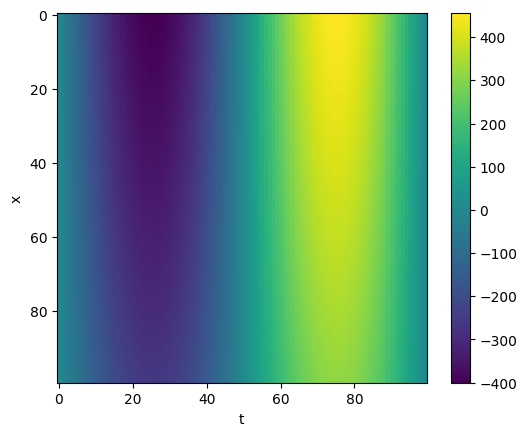

In [28]:
from matplotlib import pyplot as plt
x = jnp.linspace(0, 1, 100)
t = jnp.linspace(0, 1, 100)

grid = onp.zeros((100, 100))
for idx_x in range(100):
    for idx_t in range(100):
        _x, _t = x[idx_x], t[idx_t]
        energy = unbiasing_potential(jnp.array([_x]), time=jnp.array(_t))
        print(_x, _t, energy)
        grid[idx_x, idx_t] = energy
        
plt.imshow(grid)
plt.xlabel('t')
plt.ylabel('x')
# colorbar
plt.colorbar()
plt.show()



In [1]:
# plt.plot(unbiasing_potential(0.9 * jnp.ones((100, 1)), jnp.linspace(0, 1, 100)))
plt.plot(unbiasing_potential(jnp.linspace(0, 1, 100)[..., None], 0.9 * jnp.ones((100,))))

NameError: name 'plt' is not defined

In [31]:
B

NameError: name 'B' is not defined